In [22]:
import io
import zstandard as zstd
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


# Chess Elo Regression Notebook

This notebook is organized so you can swap feature sets and models from one place.

In [23]:
# Global configuration for experiments
DATA_PATH = "lichess_db_standard_rated_2013-03.pgn.zst"
MAX_GAMES = 150000
RANDOM_STATE = 42
TEST_SIZE = 0.2
TFIDF_CONFIG = {
    "ngram_range": (1, 3),
    "max_features": 1500,
}
FEATURE_COLUMNS_METADATA = ['TimeControl', 'ECO']
FEATURE_COLUMNS_NUMERIC = [
    'total_characters',
    'total_tokens',
    'capture_count',
    'check_count',
    'is_resignation',
    'is_decisive',
    'early_resignation',
]
FEATURE_SETS = {
    'metadata_only': ['TimeControl', 'ECO'],
    'engineered_metadata': FEATURE_COLUMNS_METADATA + FEATURE_COLUMNS_NUMERIC,
    'moves_plus_metadata': FEATURE_COLUMNS_METADATA + FEATURE_COLUMNS_NUMERIC + ['first_10_moves'],
}
MODEL_CONFIGS = {
    'lightgbm_baseline': {
        'n_estimators': 100,
        'learning_rate': 0.1,
        'random_state': RANDOM_STATE,
        'verbose': -1,
    },
    'lightgbm_text': {
        'n_estimators': 250,
        'learning_rate': 0.08,
        'num_leaves': 31,
        'random_state': RANDOM_STATE,
        'verbose': -1,
    },
}

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb


def get_first_n_moves(moves_string, n_moves=10):
    tokens = str(moves_string).split()
    return ' '.join(tokens[: n_moves * 3])


def engineer_game_features(frame):
    data = frame.copy()
    data['Moves'] = data['Moves'].fillna('').astype(str)
    data['first_10_moves'] = data['Moves'].apply(get_first_n_moves)
    data['total_characters'] = data['Moves'].str.len()
    data['total_tokens'] = data['Moves'].str.split().str.len()
    data['capture_count'] = data['Moves'].str.count('x')
    data['check_count'] = data['Moves'].str.count(r'\+')
    if 'Termination' in data.columns:
        data['is_resignation'] = data['Termination'].str.contains('resign', case=False, na=False).astype(int)
    else:
        data['is_resignation'] = 0
    if 'Result' in data.columns:
        data['is_decisive'] = data['Result'].isin(['1-0', '0-1']).astype(int)
    else:
        data['is_decisive'] = 0
    data['early_resignation'] = ((data['is_resignation'] == 1) & (data['total_tokens'] < 40)).astype(int)
    data['AverageElo'] = (data['WhiteElo'] + data['BlackElo']) / 2
    return data


def build_feature_matrix(frame, feature_set='engineered_metadata', use_tfidf=False):
    data = frame.copy()
    selected_columns = FEATURE_SETS[feature_set]
    categorical_columns = [column for column in selected_columns if column in FEATURE_COLUMNS_METADATA]
    numeric_columns = [column for column in selected_columns if column in FEATURE_COLUMNS_NUMERIC]
    text_columns = [column for column in selected_columns if column == 'first_10_moves']
    matrix_parts = []
    if numeric_columns:
        matrix_parts.append(csr_matrix(data[numeric_columns].astype(float).values))
    if categorical_columns:
        categorical_frame = pd.get_dummies(data[categorical_columns], drop_first=True).astype(float)
        matrix_parts.append(csr_matrix(categorical_frame.values))
    if use_tfidf and text_columns:
        tfidf = TfidfVectorizer(**TFIDF_CONFIG)
        text_matrix = tfidf.fit_transform(data[text_columns[0]])
        matrix_parts.append(text_matrix)
    if not matrix_parts:
        raise ValueError('No features selected for the model.')
    if len(matrix_parts) == 1:
        return matrix_parts[0]
    return hstack(matrix_parts)


def train_experiment(frame, feature_set='engineered_metadata', model_name='lightgbm_baseline', use_tfidf=False):
    data = engineer_game_features(frame)
    features = build_feature_matrix(data, feature_set=feature_set, use_tfidf=use_tfidf)
    target = data['AverageElo']
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    model = lgb.LGBMRegressor(**MODEL_CONFIGS[model_name])
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    metrics = {
        'mae': mean_absolute_error(y_test, predictions),
        'rmse': root_mean_squared_error(y_test, predictions),
    }
    return {
        'data': data,
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'predictions': predictions,
        'metrics': metrics,
    }


def summarize_runs(run_map):
    summary_rows = []
    for run_name, run_data in run_map.items():
        summary_rows.append({
            'experiment': run_name,
            'mae': run_data['metrics']['mae'],
            'rmse': run_data['metrics']['rmse'],
            'samples_tested': len(run_data['y_test']),
        })
    return pd.DataFrame(summary_rows).sort_values(['mae', 'rmse']).reset_index(drop=True)


def plot_truth_vs_prediction(run_data, title):
    y_true = run_data['y_test'].values if hasattr(run_data['y_test'], 'values') else run_data['y_test']
    y_pred = run_data['predictions']
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.scatter(y_true, y_pred, alpha=0.35, s=14)
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    plt.xlabel('True Average Elo')
    plt.ylabel('Predicted Average Elo')
    plt.title(title)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(alpha=0.3)

In [25]:
# Use the shared data-path configuration
compressed_file_path = DATA_PATH

dctx = zstd.ZstdDecompressor()

with open(compressed_file_path, "rb") as compressed_file:
    # Use a stream reader so you don't load gigabytes of chess games into RAM all at once
    with dctx.stream_reader(compressed_file) as reader:
        # Wrap it in a text decoder to read it like a normal text file
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        
        # Let's just print the first 1000 characters to see what it looks like
        preview = text_stream.read(10000)

print(preview)

[Event "Rated Bullet game"]
[Site "https://lichess.org/ykd40x8s"]
[White "esmir"]
[Black "apsu2323"]
[Result "0-1"]
[UTCDate "2013.02.28"]
[UTCTime "23:01:05"]
[WhiteElo "1575"]
[BlackElo "1894"]
[WhiteRatingDiff "-4"]
[BlackRatingDiff "+3"]
[ECO "C00"]
[Opening "Rat Defense: Small Center Defense"]
[TimeControl "0+1"]
[Termination "Time forfeit"]

1. e4 d6 2. d4 e6 3. f3 g6 4. g3 Bg7 5. h3 Nf6 6. e5 dxe5 7. dxe5 Qxd1+ 8. Kxd1 Nd5 0-1

[Event "Rated Blitz game"]
[Site "https://lichess.org/uvnt8cjg"]
[White "pingchess"]
[Black "Winner1"]
[Result "0-1"]
[UTCDate "2013.02.28"]
[UTCTime "23:01:35"]
[WhiteElo "1287"]
[BlackElo "1442"]
[WhiteRatingDiff "-11"]
[BlackRatingDiff "+6"]
[ECO "A00"]
[Opening "Van Geet Opening"]
[TimeControl "300+1"]
[Termination "Time forfeit"]

1. Nc3 d5 2. e4 d4 3. Nd5 c6 4. Nf4 e5 5. Nh5 Qg5 6. Qf3 Bg4 7. Nf6+ Nxf6 8. h4 Qh5 9. Qg3 Nxe4 10. Qd3 Bf5 11. Be2 Qg6 12. Nf3 Nc5 13. Qc4 Bxc2 14. Nxe5 Qf5 15. Qxd4 Be4 16. f3 Bd5 17. d3 Bd6 18. f4 Ne6 19. Qf2 Bc5 20. Be3

In [26]:
compressed_file_path = DATA_PATH

games_list = []
max_games = MAX_GAMES

dctx = zstd.ZstdDecompressor()

with open(compressed_file_path, "rb") as compressed_file:
    with dctx.stream_reader(compressed_file) as reader:
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        
        current_game = {}
        
        for line in text_stream:
            line = line.strip()
            
            # 1. Capture the metadata lines like [WhiteElo "1575"]
            if line.startswith('['):
                # Split by space to get the tag name (e.g., WhiteElo)
                tag_name = line.split(' ')[0][1:] 
                # Split by quotes to get the value inside them (e.g., 1575)
                value = line.split('"')[1]         
                
                # Keep only the simple things we care about right now
                if tag_name in ['WhiteElo', 'BlackElo', 'TimeControl', 'Opening','ECO','Termination','Result']:
                    current_game[tag_name] = value
            
            # 2. Capture the move line (always starts with '1.')
            elif line.startswith('1.'):
                current_game['Moves'] = line
                
                # Save the completed game data to our list
                if 'WhiteElo' in current_game and 'BlackElo' in current_game:
                    games_list.append(current_game)
                
                # Reset the dictionary for the next game in the file
                current_game = {}
                
                if len(games_list) >= max_games:
                    break

# Convert the list of dictionaries into a Pandas DataFrame
df = pd.DataFrame(games_list)

# Convert Elo ratings from text strings to actual integers so we can do math
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

df = df.dropna(subset=['WhiteElo', 'BlackElo'])

# Now turn them into proper integers safely
df['WhiteElo'] = df['WhiteElo'].astype(int)
df['BlackElo'] = df['BlackElo'].astype(int)
df['Moves'] = df['Moves'].fillna('').astype(str)

df = engineer_game_features(df)

# Print out the first 5 rows to see what it looks like
df.head()

,Result,WhiteElo,BlackElo,ECO,Opening,TimeControl,Termination,Moves,first_10_moves,total_characters,total_tokens,capture_count,check_count,is_resignation,is_decisive,early_resignation,AverageElo
0,0-1,1575,1894,C00,Rat Defense: Small Center Defense,0+1,Time forfeit,1. e4 d6 2. d4 e6 3. f3 g6 4. g3 Bg7 5. h3 Nf6...,1. e4 d6 2. d4 e6 3. f3 g6 4. g3 Bg7 5. h3 Nf6...,87,25,4,1,0,1,0,1734.5
1,0-1,1287,1442,A00,Van Geet Opening,300+1,Time forfeit,1. Nc3 d5 2. e4 d4 3. Nd5 c6 4. Nf4 e5 5. Nh5 ...,1. Nc3 d5 2. e4 d4 3. Nd5 c6 4. Nf4 e5 5. Nh5 ...,340,85,11,7,0,1,0,1364.5
2,0-1,1567,1421,C20,King's Pawn Game: Napoleon Attack,1800+30,Time forfeit,1. e4 e5 2. Qf3 Nf6 3. Bc4 Bc5 4. Ne2 O-O 5. N...,1. e4 e5 2. Qf3 Nf6 3. Bc4 Bc5 4. Ne2 O-O 5. N...,101,28,3,0,0,1,0,1494.0
3,0-1,1250,1387,C44,King's Pawn Game: Dresden Opening,360+3,Time forfeit,1. e4 e5 2. Nf3 Nc6 3. c4 Bc5 4. Nc3 Nf6 5. d3...,1. e4 e5 2. Nf3 Nc6 3. c4 Bc5 4. Nc3 Nf6 5. d3...,262,67,10,2,0,1,0,1318.5
4,1-0,1623,1805,A00,Hungarian Opening,60+0,Time forfeit,1. g3 d6 2. Bg2 e5 3. d3 Nf6 4. Bd2 Be7 5. Bc3...,1. g3 d6 2. Bg2 e5 3. d3 Nf6 4. Bd2 Be7 5. Bc3...,484,120,19,6,0,1,0,1714.0


In [27]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


In [28]:
# Baseline experiment: engineered metadata only
baseline_run = train_experiment(
    df,
    feature_set='engineered_metadata',
    model_name='lightgbm_baseline',
    use_tfidf=False,
)

print("--- Baseline Experiment ---")
print(f"Mean Absolute Error (MAE): {baseline_run['metrics']['mae']:.2f} Elo points")
print(f"Root Mean Squared Error (RMSE): {baseline_run['metrics']['rmse']:.2f} Elo points")

--- Baseline Experiment ---
Mean Absolute Error (MAE): 120.16 Elo points
Root Mean Squared Error (RMSE): 153.30 Elo points


c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [29]:
# Text-enhanced experiment: first 10 moves plus metadata
text_run = train_experiment(
    df,
    feature_set='moves_plus_metadata',
    model_name='lightgbm_text',
    use_tfidf=True,
)

print("--- Text Experiment ---")
print(f"Mean Absolute Error (MAE): {text_run['metrics']['mae']:.2f} Elo points")
print(f"Root Mean Squared Error (RMSE): {text_run['metrics']['rmse']:.2f} Elo points")

--- Text Experiment ---
Mean Absolute Error (MAE): 107.17 Elo points
Root Mean Squared Error (RMSE): 137.50 Elo points


c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Results Comparison

Use this section to compare experiments and review regression plots together.

In [30]:
# Compare the current experiments in one place
results_summary = summarize_runs({
    'engineered_metadata_baseline': baseline_run,
    'first_10_moves_text': text_run,
})

results_summary

,experiment,mae,rmse,samples_tested
0,first_10_moves_text,107.172815,137.504432,29945
1,engineered_metadata_baseline,120.164137,153.295576,29945


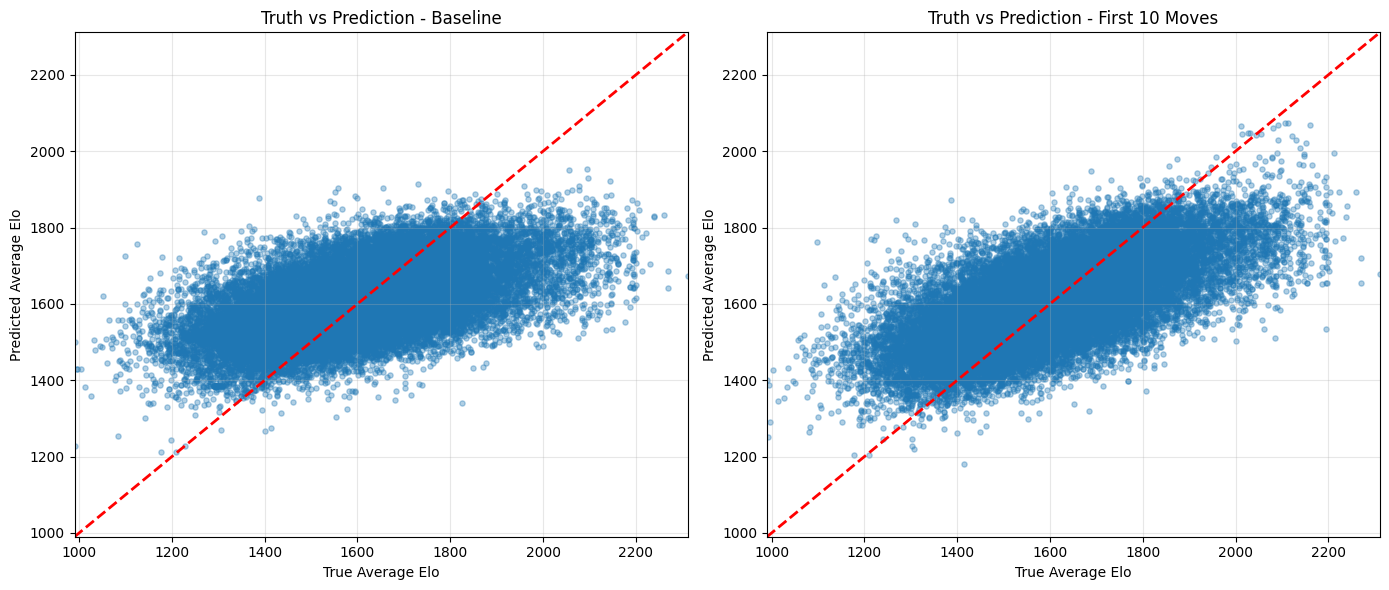

In [31]:
# Compare the regression plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

plt.sca(axes[0])
plot_truth_vs_prediction(baseline_run, 'Truth vs Prediction - Baseline')

plt.sca(axes[1])
plot_truth_vs_prediction(text_run, 'Truth vs Prediction - First 10 Moves')

plt.tight_layout()
plt.show()

In [32]:
# Exact modal Elo (most common) values
white_counts = df['WhiteElo'].value_counts()
white_mode_count = white_counts.max()
white_modes = white_counts[white_counts == white_mode_count].index.tolist()

black_counts = df['BlackElo'].value_counts()
black_mode_count = black_counts.max()
black_modes = black_counts[black_counts == black_mode_count].index.tolist()

combined = pd.concat([df['WhiteElo'], df['BlackElo']], ignore_index=True)
combined_counts = combined.value_counts()
combined_mode_count = combined_counts.max()
combined_modes = combined_counts[combined_counts == combined_mode_count].index.tolist()

print(f"White mode(s): {white_modes} (count={white_mode_count})")
print(f"Black mode(s): {black_modes} (count={black_mode_count})")
print(f"Combined mode(s): {combined_modes} (count={combined_mode_count})")

print('\nTop 10 most common Elo values (combined):')
print(combined_counts.head(10))

White mode(s): [1500] (count=2384)
Black mode(s): [1500] (count=3503)
Combined mode(s): [1500] (count=5887)

Top 10 most common Elo values (combined):
1500    5887
1662     630
1549     626
1574     594
1687     591
1583     587
1679     587
1554     587
1541     587
1548     585
Name: count, dtype: int64
